<a href="https://colab.research.google.com/github/sumitgoski/neo_spitzer_spectra/blob/main/Deriving_Asteroid_Spectra_from_Spitzer_IRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation

In [ ]:
!pip install PyAstronomy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.0/775.0 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.2/101.2 kB 10.7 MB/s eta 0:00:00
  Created wheel for PyAstronomy: filename=PyAstronomy-0.21.0-py3-none-any.whl size=551636 sha256=5e8ffb743d586d7dcffea2720895d7e81b6930ceab4e1a792ca011e951524c30
  Stored in directory: /root/.cache/pip/wheels/af/0d/17/fd077134497d5853ed7e740e10f9b9a2b7712f4468911d6a07
Successfully built PyAstronomy


In [ ]:
!git clone https://github.com/MigoMueller/NEATM.git

Cloning into 'NEATM'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 78 (delta 6), reused 11 (delta 4), pack-reused 61
Receiving objects: 100% (78/78), 33.61 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [ ]:
!cd /content/NEATM/neatm/c++

In [ ]:
!apt-get install make

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
make is already the newest version (4.3-4.1build1).
make set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
cd /content/NEATM/neatm/c++

/content/NEATM/neatm/c++


In [ ]:
!make

g++ -c -O3 main.cpp -o main.o
g++ -c -O3 neatm.cpp -o neatm.o
g++ -c -O3 neatm_input_file.cpp -o neatm_input_file.o
g++ -c -O3 integral.cpp -o integral.o
g++ -O3 -o neatm main.o neatm.o neatm_input_file.o integral.o 


In [ ]:
!echo $PATH

/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [ ]:
!sudo mv /content/NEATM/neatm/c++/neatm /usr/local/bin/

In [ ]:
!neatm

Wrong number of command line arguments!
Please provide four or eight arguments:
Four arguments:
1. NEATM parameter file name
2. lambda (micron)
3. eta
4. pV
Eight arguments:
1. H
2. G
3. alpha (deg)
4. r (AU)
5. delta (AU)
6. lambda (micron)
7. eta
8. pV


In [ ]:
# M.Mueller@astro.rug.nl, 2016/09/05+
# Wrapper around my NEATM executable.
# Output will be in mJy (default) or W/m^2/micron.
# Wavelengths can be an array (iterable) or a scalar Quantity;
# output will be a list of Quantitites or a single Quantity, resp.

from __future__ import print_function
import subprocess
import numpy as np
from astropy import units as u

def neatm(h,g,alpha,r,delta,wavelengths,eta,pv, mJy=True):


    try :
        isIterable = True
        for wav in wavelengths :
            pass
    except TypeError :
        isIterable = False
    if isIterable :
        return [neatm(h,g,alpha,r,delta,wav,eta,pv,mJy=mJy) for wav in wavelengths]
    # wavelengths is scalar:
    try:
        alphaDeg=alpha.to_value(u.degree)
        rAU=r.to_value(u.AU)
        deltaAU=delta.to_value(u.AU)
        lambdaMu=wavelengths.to_value(u.micron)
    except AttributeError:
        print("alpha, r, delta, and lambdaMu must be astropy quantities")
        raise
    except u.UnitConversionError:
        print("Alpha must be an angle; r, delta, and lambdaMu must be (wave-)lengths")
        raise
    cmd=['neatm']
    for var in [h,g,alphaDeg,rAU,deltaAU,lambdaMu,eta,pv]:
        cmd.append(str(var))
    #print(cmd)
    process=subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    output, cerr = process.communicate()
    output = output.split()
    if mJy:
        return float(output[1]) / 1000 # *u.mJy units are in u.mJy by dividing by 1000, mJy is converted to Jy
    else:
        return float(output[0])*u.Watt/u.meter**2/u.micron



h = 5.85
g = 0.12
alpha = 20.86 * u.degree
r = 2.82323 * u.AU
delta = 2.5682 * u.AU
wavelengths = 6* u.micron
eta = 1
pv = 0.38
mJy = True
neatm(h,g,alpha, r, delta, wavelengths, eta, pv, mJy)


0.237656

In [ ]:
# Import necessary libraries
from astropy import units as u
from astropy.coordinates import Angle
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import os

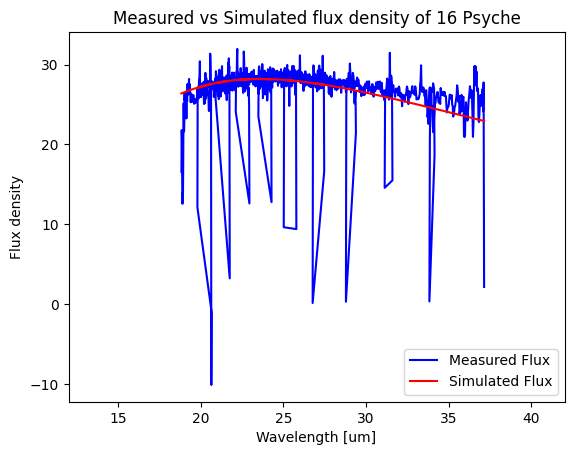

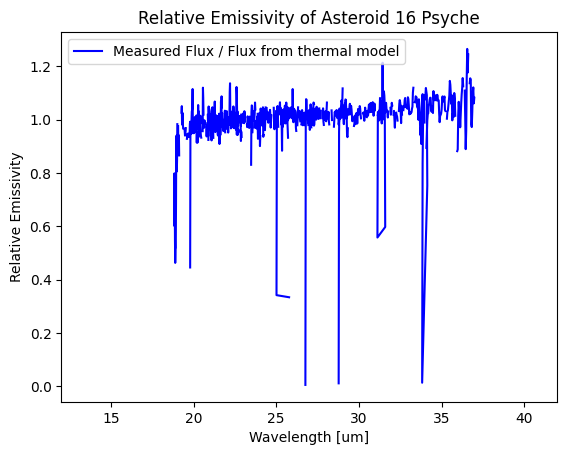

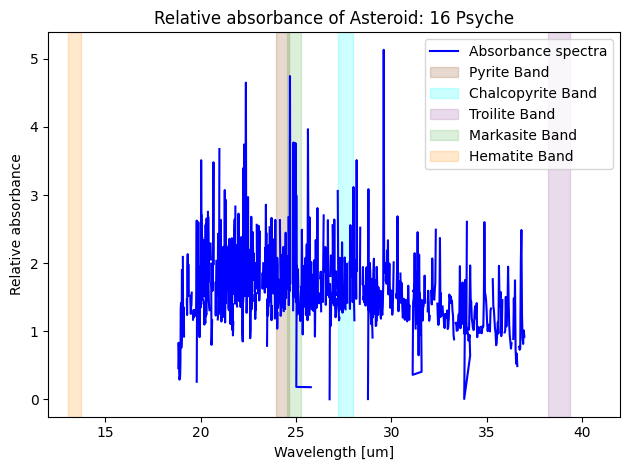

In [ ]:

# Import necessary libraries
from astropy import units as u
from astropy.coordinates import Angle
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the NEATM function
def neatm(h, g, alpha, r, delta, wavelength, eta, pv, mJy=True):
    try:
        alphaDeg = alpha.to_value(u.degree)
        rAU = r.to_value(u.AU)
        deltaAU = delta.to_value(u.AU)
        lambdaMu = wavelength.to_value(u.micron)
    except AttributeError:
        print("alpha, r, delta, and lambdaMu must be astropy quantities")
        raise
    except u.UnitConversionError:
        print("Alpha must be an angle; r, delta, and lambdaMu must be (wave-)lengths")
        raise
    cmd = ['neatm']
    for var in [h, g, alphaDeg, rAU, deltaAU, lambdaMu, eta, pv]:
        cmd.append(str(var))
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    output, cerr = process.communicate()
    output = output.split()
    if mJy:
        return float(output[1]) / 1000  # units are in u.mJy by dividing by 1000, mJy is converted to Jy
    else:
        return float(output[0]) * u.Watt / u.meter**2 / u.micron


# Define the TelescopeData class
class telescope_data:
    def __init__(self, csv_file_path):
        self.csv_file_path = csv_file_path
        self.data_df = pd.read_csv(csv_file_path)
        if 'flux_density' not in self.data_df.columns:
            raise KeyError("The column 'flux_density' is missing from the data.")
        if 'error' not in self.data_df.columns:
            raise KeyError("The column 'error' is missing from the data.")

    def get_wavelength_values_pandas(self):
        wavelengths = self.data_df['wavelength'].tolist()
        return wavelengths

    def save_results(self, example_flux):
        self.data_df['simulated_flux'] = example_flux
        # Save the updated DataFrame back to the CSV file
        self.data_df.to_csv(self.csv_file_path, index=False)

    def calculate_thermal_flux(self, h, g, alpha, r, delta, wavelengths, eta, pv, mJy):
        self.data_df['Flux density from thermal model'] = [
            neatm(h, g, alpha, r, delta, wav * u.micron, eta, pv, mJy) for wav in wavelengths
        ]
        self.data_df.to_csv(self.csv_file_path, index=False)
        return self.data_df['Flux density from thermal model']

    def calculate_flux_ratio(self):
        self.data_df['Flux ratio'] = (self.data_df['flux_density'] - (self.data_df['error'] / 2)) / self.data_df['Flux density from thermal model']
        self.data_df.to_csv(self.csv_file_path, index=False)
        return self.data_df['Flux ratio']

    def plot_flux_comparison(self, asteroid_name, x_range):
        plt.plot(self.data_df['wavelength'], self.data_df['flux_density'], label='Measured Flux', color='blue')
        plt.plot(self.data_df['wavelength'], self.data_df['Flux density from thermal model'], label='Simulated Flux', color='red')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Flux density')
        plt.title(f'Measured vs Simulated flux density of {asteroid_name}')
        plt.legend()
        plt.xlim(x_range)
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_comparison_flux_plot.png'), dpi=1000)
        plt.show()

    def plot_spectra(self, x_range, asteroid_name):
        plt.plot(self.data_df['wavelength'], self.data_df['Flux ratio'], label='Measured Flux / Flux from thermal model', color='blue')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Relative Emissivity')
        plt.title(f'Relative Emissivity of Asteroid {asteroid_name}')
        plt.legend()
        plt.xlim(x_range)
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_spectra_plot.png'), dpi=1000)
        plt.show()

    def plot_absorption_spectra(self, x_range, asteroid_name, bands=None):
        relative_emissivity = (self.data_df['flux_density'] + (self.data_df['error'] / 2)) / self.data_df['Flux density from thermal model']
        self.data_df['Absorbance'] = - np.log10(np.abs(1 - relative_emissivity))
        plt.plot(self.data_df['wavelength'], self.data_df['Absorbance'], label='Absorbance spectra', color='blue')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Relative absorbance')
        plt.title(f'Relative absorbance of Asteroid: {asteroid_name}')
        plt.legend()
        plt.xlim(x_range)
        if bands:
            for band_start, band_end, band_label, color_given in bands:
                plt.axvspan(band_start, band_end, color=color_given, alpha=0.2, label=f'{band_label} Band')
        plt.legend(loc='upper right')
        plt.tight_layout()
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_absorbance_plot.png'), dpi=1000)
        plt.show()


# Example usage
h = 5.85
g = 0.12
alpha = 20.86 * u.degree
r = 2.82323 * u.AU
delta = 2.5682 * u.AU
eta = 0.95
pv = 0.238
mJy = True
xrange = (12, 42)
asteroid_name = '16 Psyche'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#8B4513'),
    (27.19, 28.01, 'Chalcopyrite', '#00FFFF'),
    (38.22, 39.38, 'Troilite', '#984EA3'),
    (24.53, 25.27, 'Markasite', '#4DAF4A'),
    (13.02, 13.71, 'Hematite', '#FF8C00')
]

file_path = '/content/psyche_0_to_35microns.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength']
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)


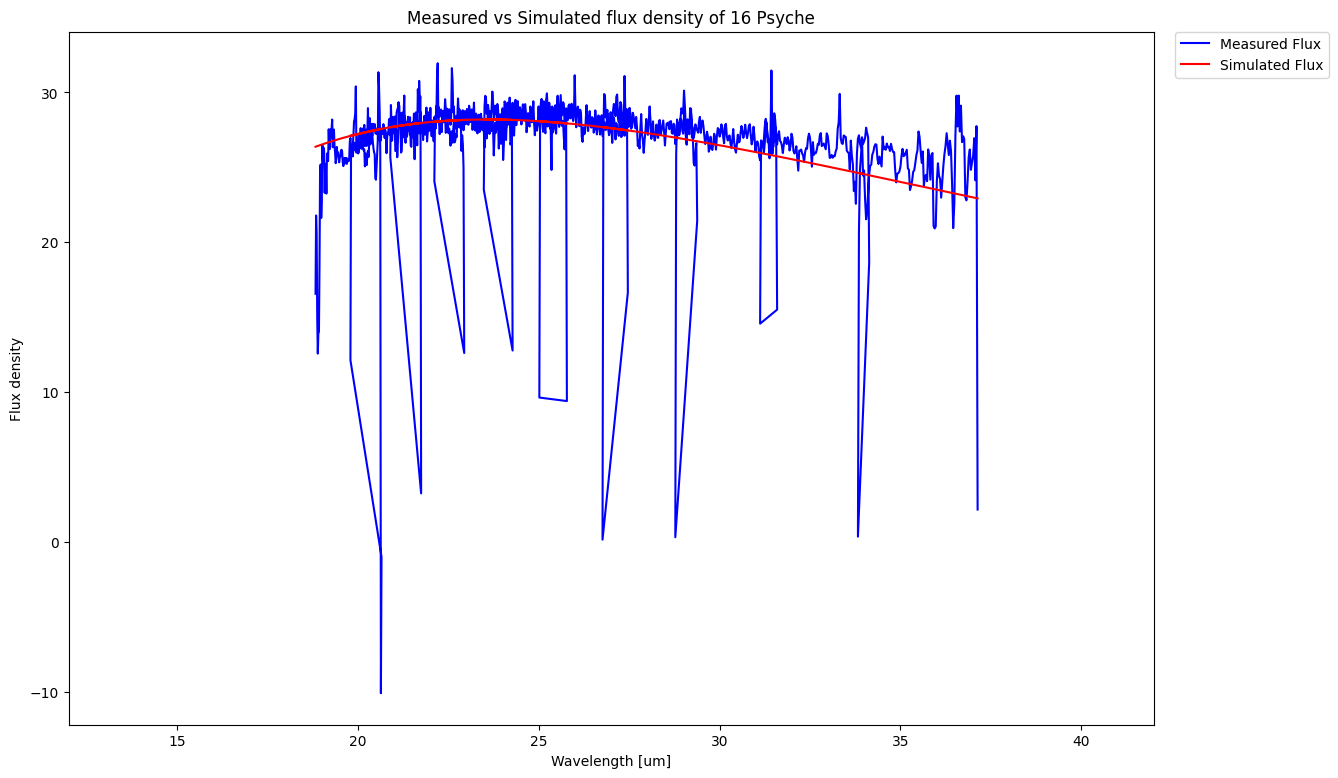

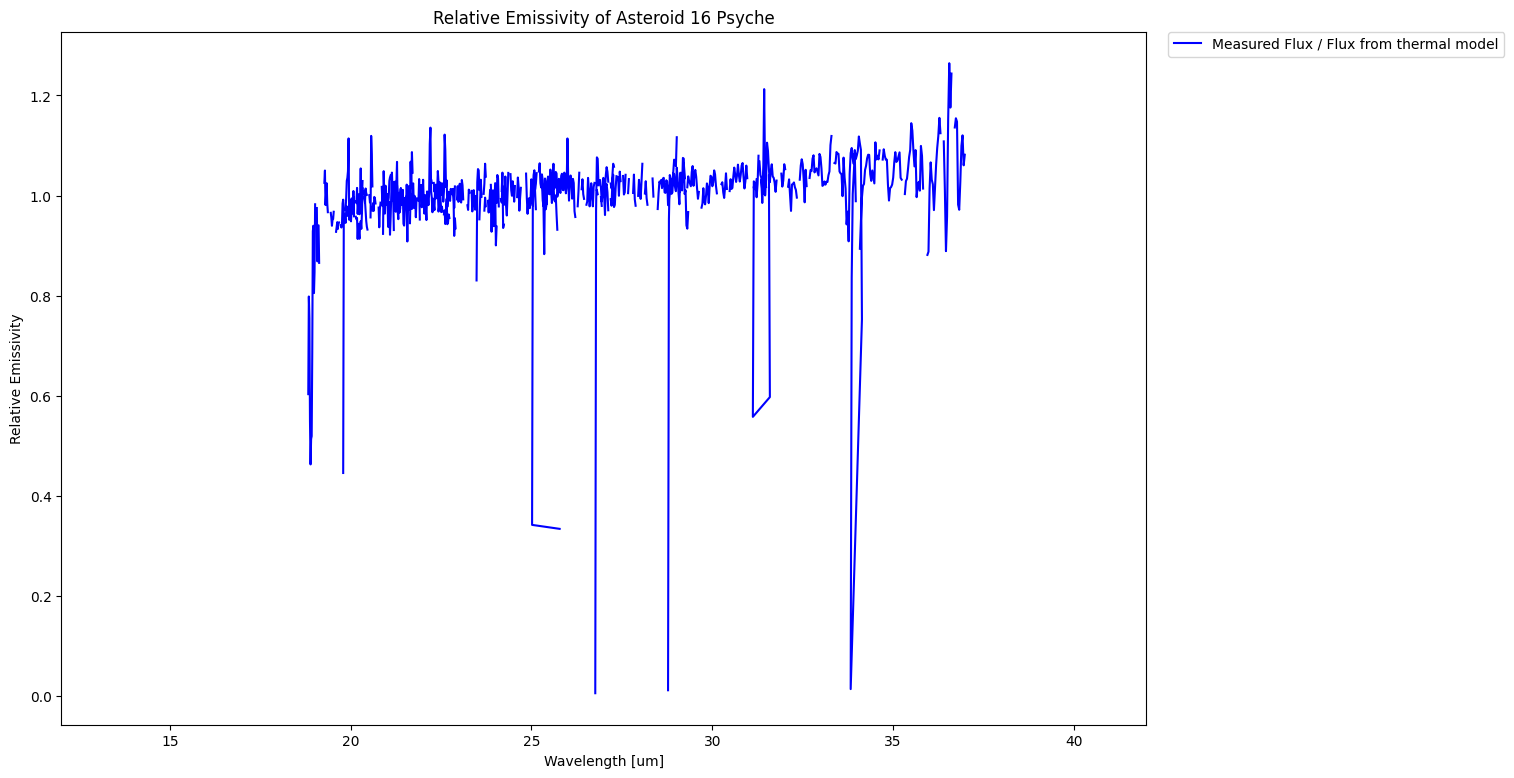

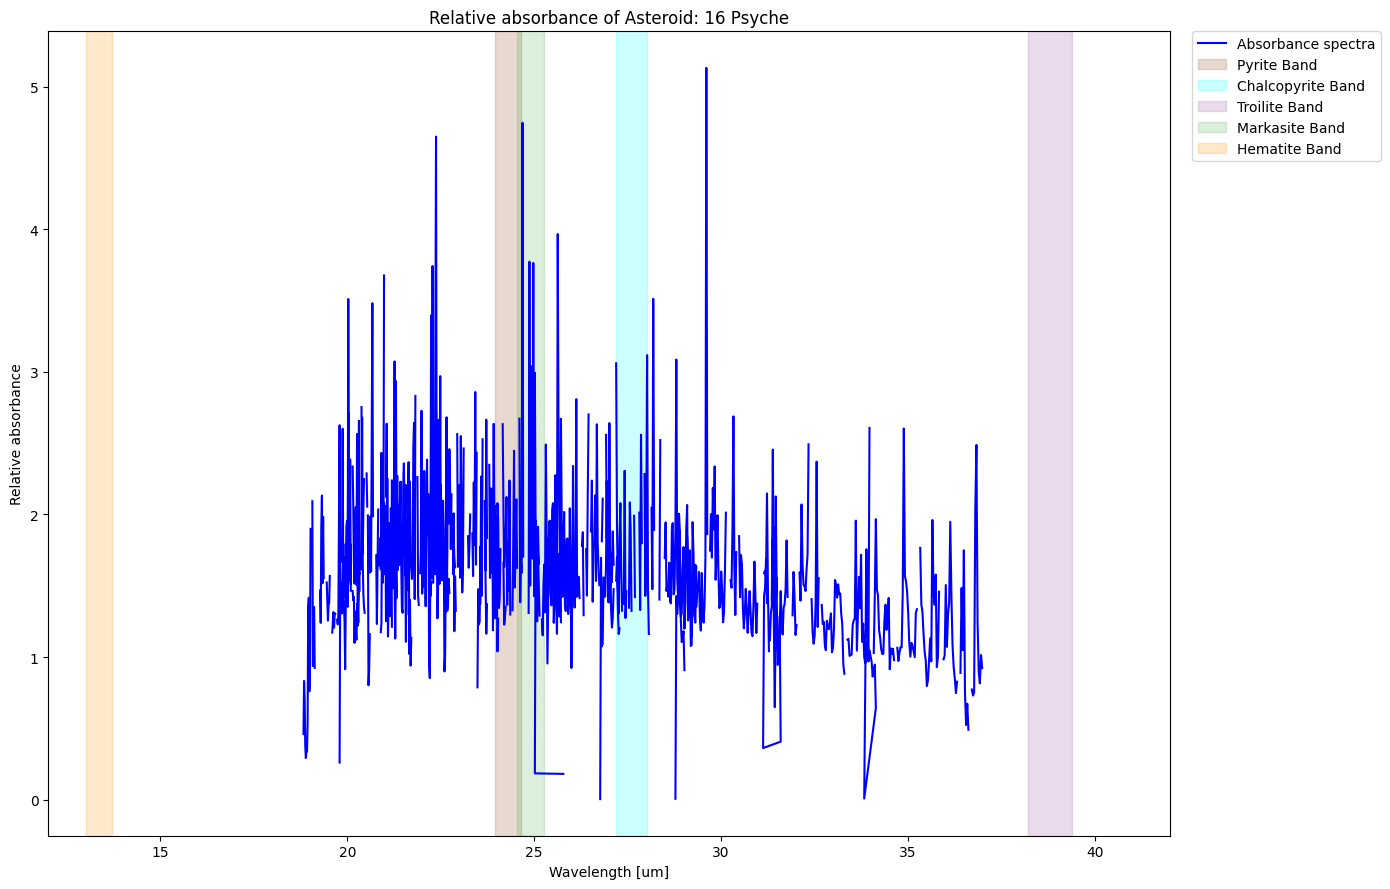

In [ ]:

# Import necessary libraries
from astropy import units as u
from astropy.coordinates import Angle
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the NEATM function
def neatm(h, g, alpha, r, delta, wavelength, eta, pv, mJy=True):
    try:
        alphaDeg = alpha.to_value(u.degree)
        rAU = r.to_value(u.AU)
        deltaAU = delta.to_value(u.AU)
        lambdaMu = wavelength.to_value(u.micron)
    except AttributeError:
        print("alpha, r, delta, and lambdaMu must be astropy quantities")
        raise
    except u.UnitConversionError:
        print("Alpha must be an angle; r, delta, and lambdaMu must be (wave-)lengths")
        raise
    cmd = ['neatm']
    for var in [h, g, alphaDeg, rAU, deltaAU, lambdaMu, eta, pv]:
        cmd.append(str(var))
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    output, cerr = process.communicate()
    output = output.split()
    if mJy:
        return float(output[1]) / 1000  # units are in u.mJy by dividing by 1000, mJy is converted to Jy
    else:
        return float(output[0]) * u.Watt / u.meter**2 / u.micron


# Define the TelescopeData class
class telescope_data:
    def __init__(self, csv_file_path):
        self.csv_file_path = csv_file_path
        self.data_df = pd.read_csv(csv_file_path)
        if 'flux_density' not in self.data_df.columns:
            raise KeyError("The column 'flux_density' is missing from the data.")
        if 'error' not in self.data_df.columns:
            raise KeyError("The column 'error' is missing from the data.")

    def get_wavelength_values_pandas(self):
        wavelengths = self.data_df['wavelength'].tolist()
        return wavelengths

    def save_results(self, example_flux):
        self.data_df['simulated_flux'] = example_flux
        # Save the updated DataFrame back to the CSV file
        self.data_df.to_csv(self.csv_file_path, index=False)

    def calculate_thermal_flux(self, h, g, alpha, r, delta, wavelengths, eta, pv, mJy):
        self.data_df['Flux density from thermal model'] = [
            neatm(h, g, alpha, r, delta, wav * u.micron, eta, pv, mJy) for wav in wavelengths
        ]
        self.data_df.to_csv(self.csv_file_path, index=False)
        return self.data_df['Flux density from thermal model']

    def calculate_flux_ratio(self):
        self.data_df['Flux ratio'] = (self.data_df['flux_density'] - (self.data_df['error'] / 2)) / self.data_df['Flux density from thermal model']
        self.data_df.to_csv(self.csv_file_path, index=False)
        return self.data_df['Flux ratio']

    def plot_flux_comparison(self, asteroid_name, x_range):
        plt.figure(figsize=(14, 9))
        plt.plot(self.data_df['wavelength'], self.data_df['flux_density'], label='Measured Flux', color='blue')
        plt.plot(self.data_df['wavelength'], self.data_df['Flux density from thermal model'], label='Simulated Flux', color='red')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Flux density')
        plt.title(f'Measured vs Simulated flux density of {asteroid_name}')
        plt.xlim(x_range)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_comparison_flux_plot.png'), dpi=1000, bbox_inches='tight')
        plt.show()

    def plot_spectra(self, x_range, asteroid_name):
        plt.figure(figsize=(14, 9))
        plt.plot(self.data_df['wavelength'], self.data_df['Flux ratio'], label='Measured Flux / Flux from thermal model', color='blue')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Relative Emissivity')
        plt.title(f'Relative Emissivity of Asteroid {asteroid_name}')
        plt.xlim(x_range)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_spectra_plot.png'), dpi=1000, bbox_inches='tight')
        plt.show()

    def plot_absorption_spectra(self, x_range, asteroid_name, bands=None):
        plt.figure(figsize=(14, 9))
        relative_emissivity = (self.data_df['flux_density'] + (self.data_df['error'] / 2)) / self.data_df['Flux density from thermal model']
        self.data_df['Absorbance'] = - np.log10(np.abs(1 - relative_emissivity))
        plt.plot(self.data_df['wavelength'], self.data_df['Absorbance'], label='Absorbance spectra', color='blue')
        plt.xlabel('Wavelength [um]')
        plt.ylabel('Relative absorbance')
        plt.title(f'Relative absorbance of Asteroid: {asteroid_name}')
        plt.xlim(x_range)
        if bands:
            for band_start, band_end, band_label, color_given in bands:
                plt.axvspan(band_start, band_end, color=color_given, alpha=0.2, label=f'{band_label} Band')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout()
        save_directory = '/content/Asteroid/'
        os.makedirs(save_directory, exist_ok=True)
        plt.savefig(os.path.join(save_directory, f'{asteroid_name}_absorbance_plot.png'), dpi=1000, bbox_inches='tight')
        plt.show()


# Example usage
h = 5.85
g = 0.12
alpha = 20.86 * u.degree
r = 2.82323 * u.AU
delta = 2.5682 * u.AU
eta = 0.95
pv = 0.238
mJy = True
xrange = (12, 42)
asteroid_name = '16 Psyche'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#8B4513'),
    (27.19, 28.01, 'Chalcopyrite', '#00FFFF'),
    (38.22, 39.38, 'Troilite', '#984EA3'),
    (24.53, 25.27, 'Markasite', '#4DAF4A'),
    (13.02, 13.71, 'Hematite', '#FF8C00')
]

file_path = '/content/psyche_0_to_35microns.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength']
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)


In [ ]:
def rgba_to_normalized_rgb(color):
    color = color.replace('rgba(', '').replace(')', '').split(',')
    return tuple(float(c) / 255 if i < 3 else float(c) for i, c in enumerate(color))


# Psyche


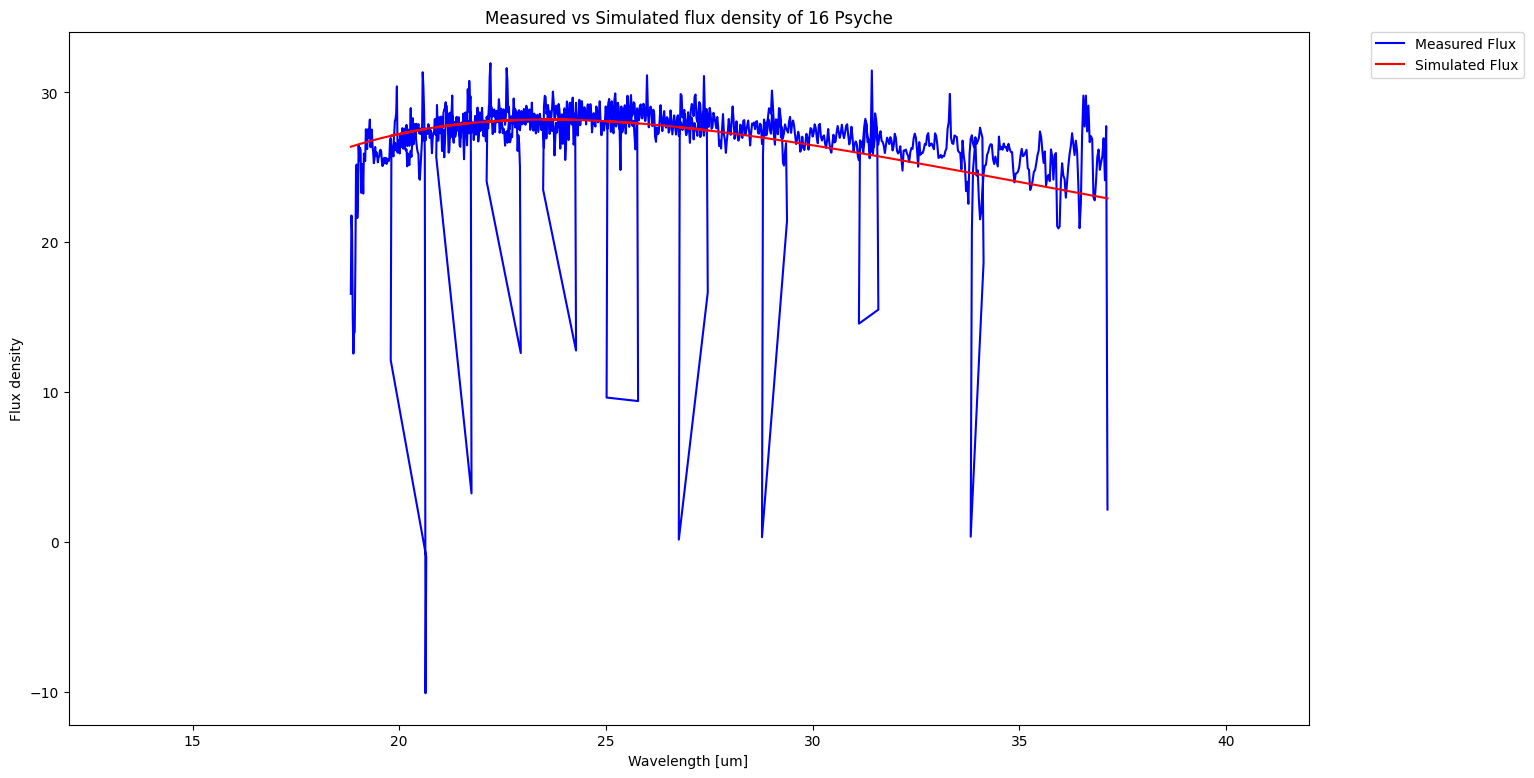

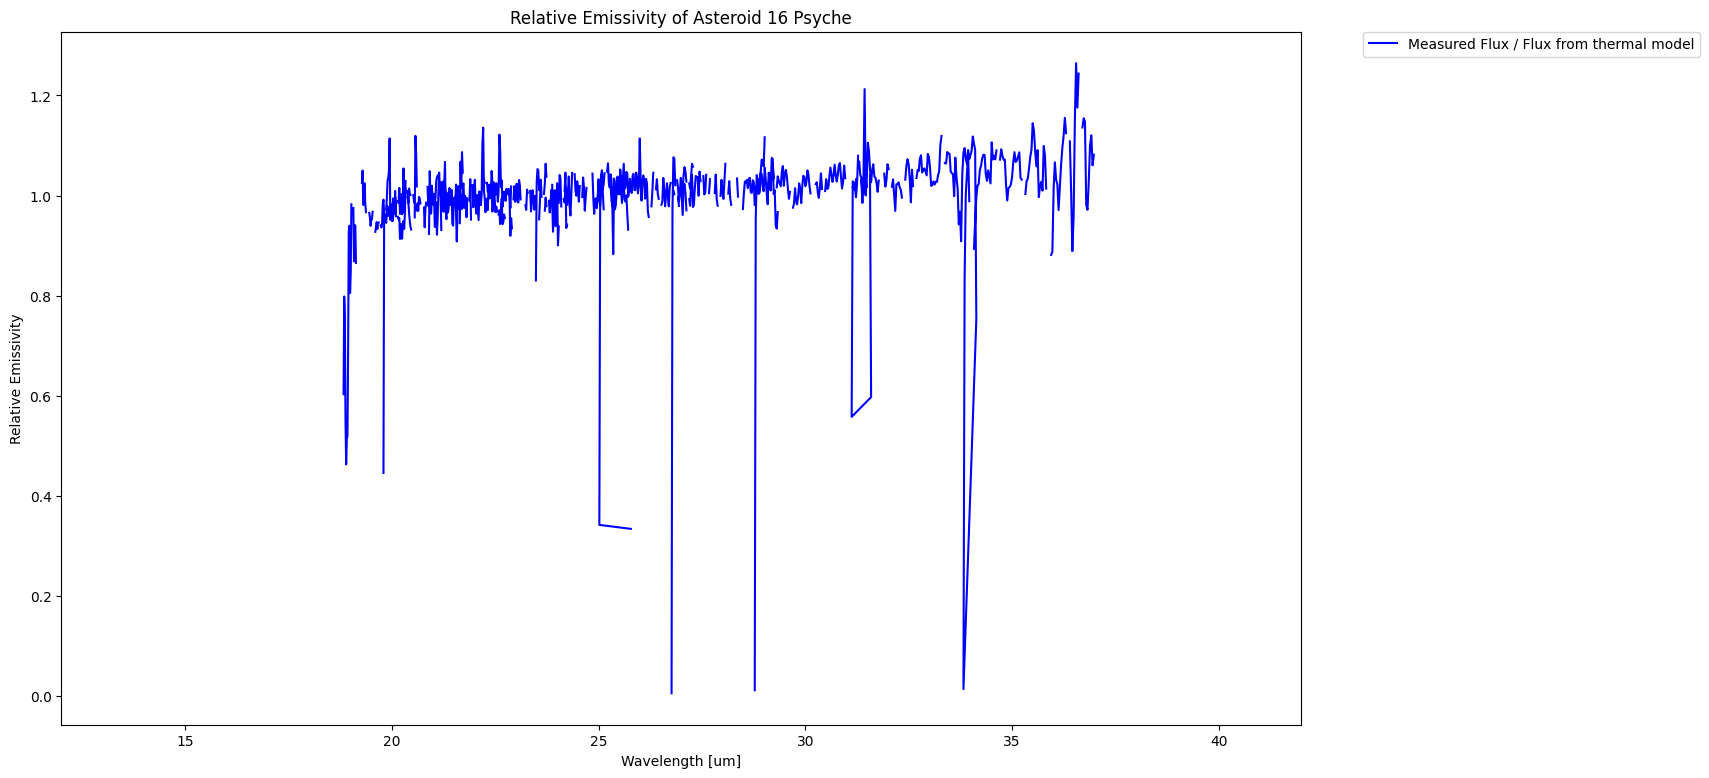

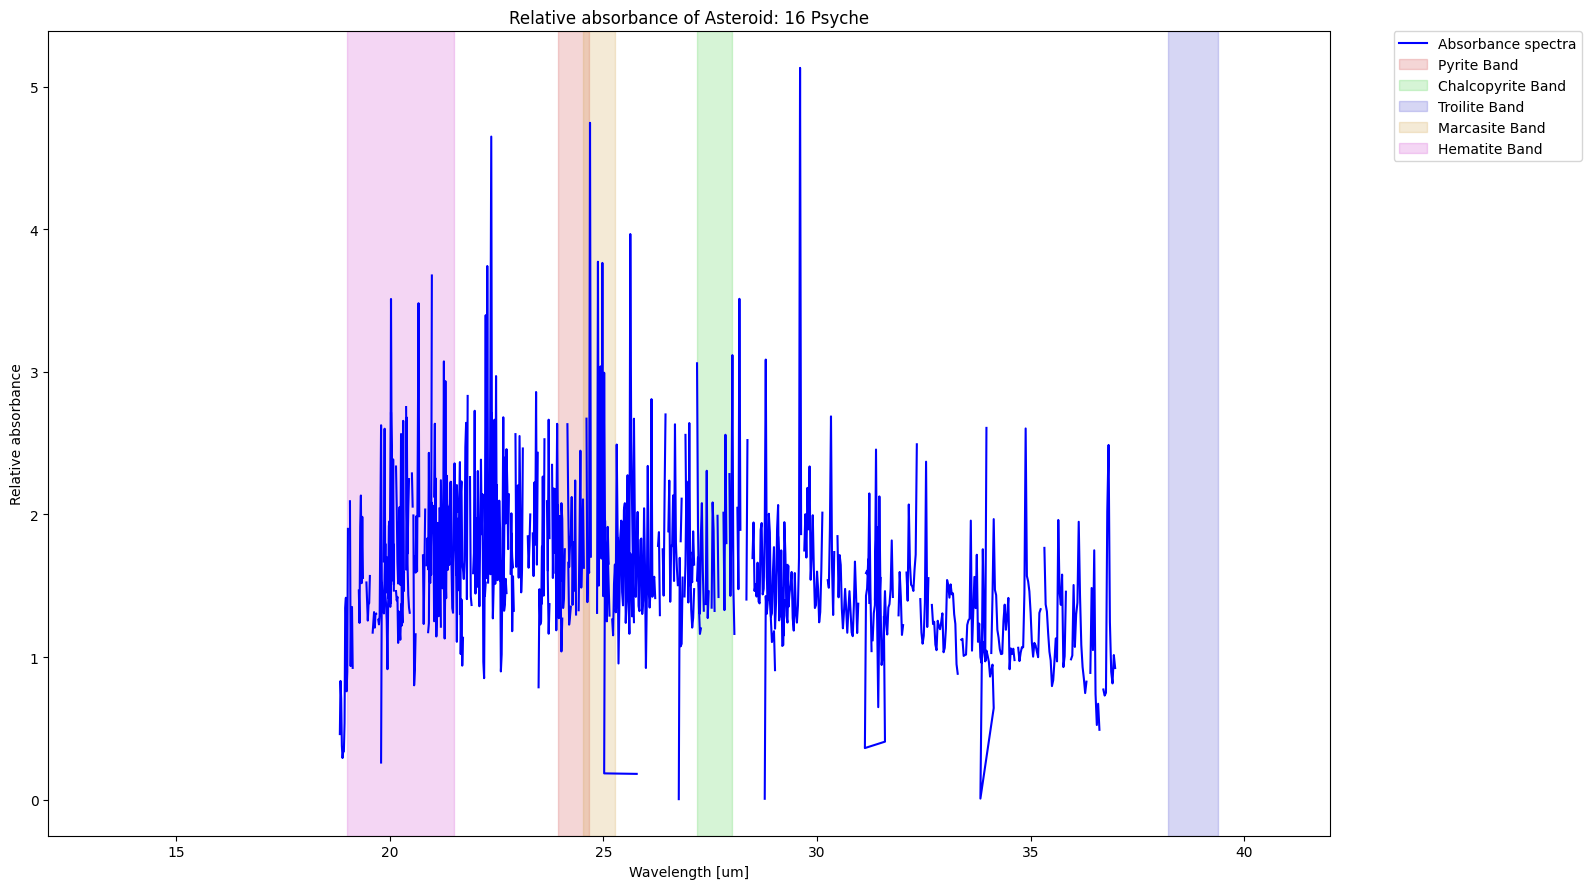

In [ ]:
# Example usage
h = 5.85
g = 0.12
alpha = 20.86 * u.degree
r = 2.82323 * u.AU
delta = 2.5682 * u.AU
eta = 0.95
pv = 0.238
mJy = True
xrange = (12, 42)
asteroid_name = '16 Psyche'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#cc3333'),       # Dark Red
    (27.19, 28.01, 'Chalcopyrite', '#33cc33'), # Dark Green
    (38.22, 39.38, 'Troilite', '#3333cc'),     # Dark Blue
    (24.53, 25.27, 'Marcasite', '#cc9933'),    # Dark Yellow
    (19, 21.5, 'Hematite', '#cc33cc')          # Dark Magenta
]

file_path = '/content/psyche_0_to_35microns.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength']
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)

# Hektor


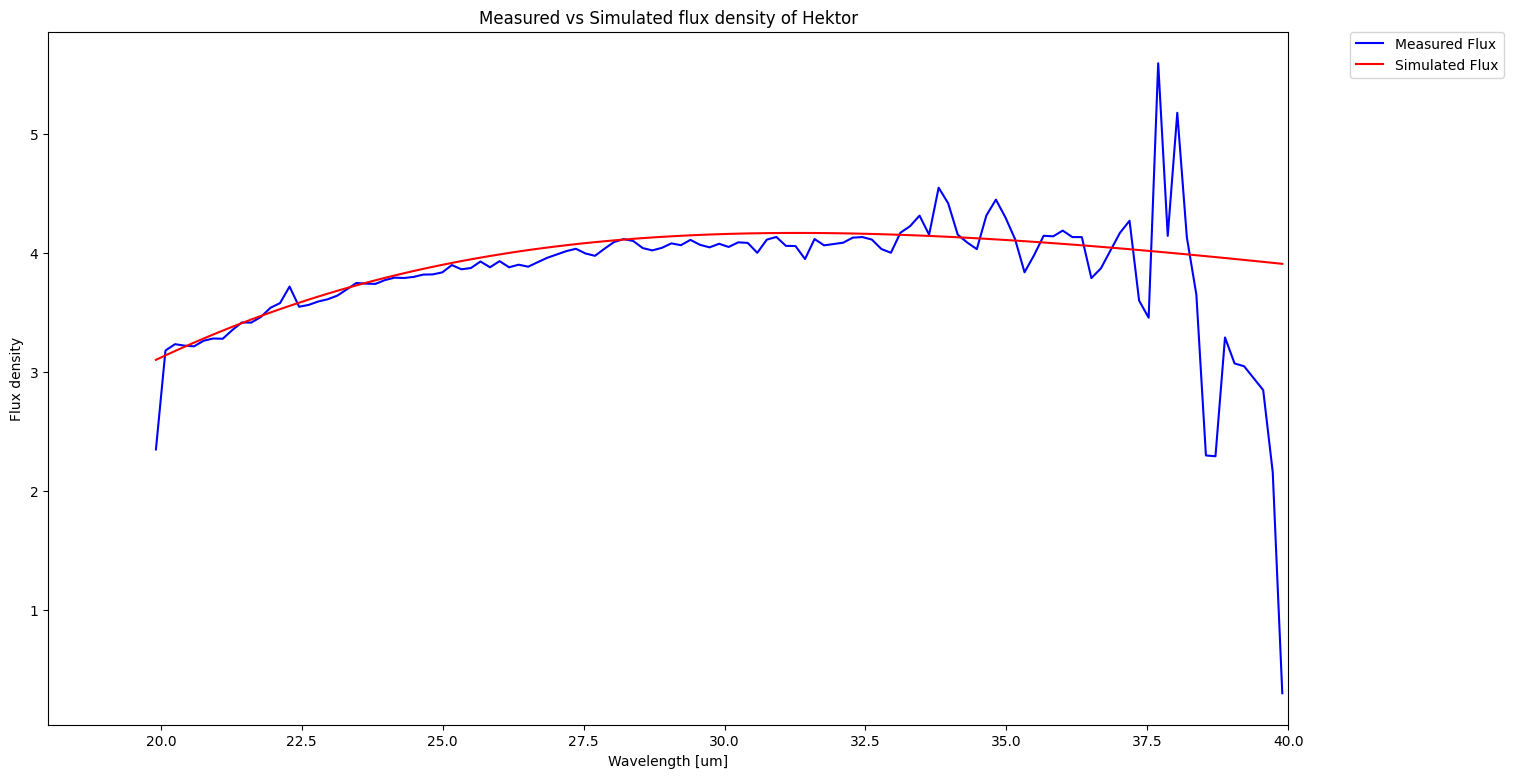

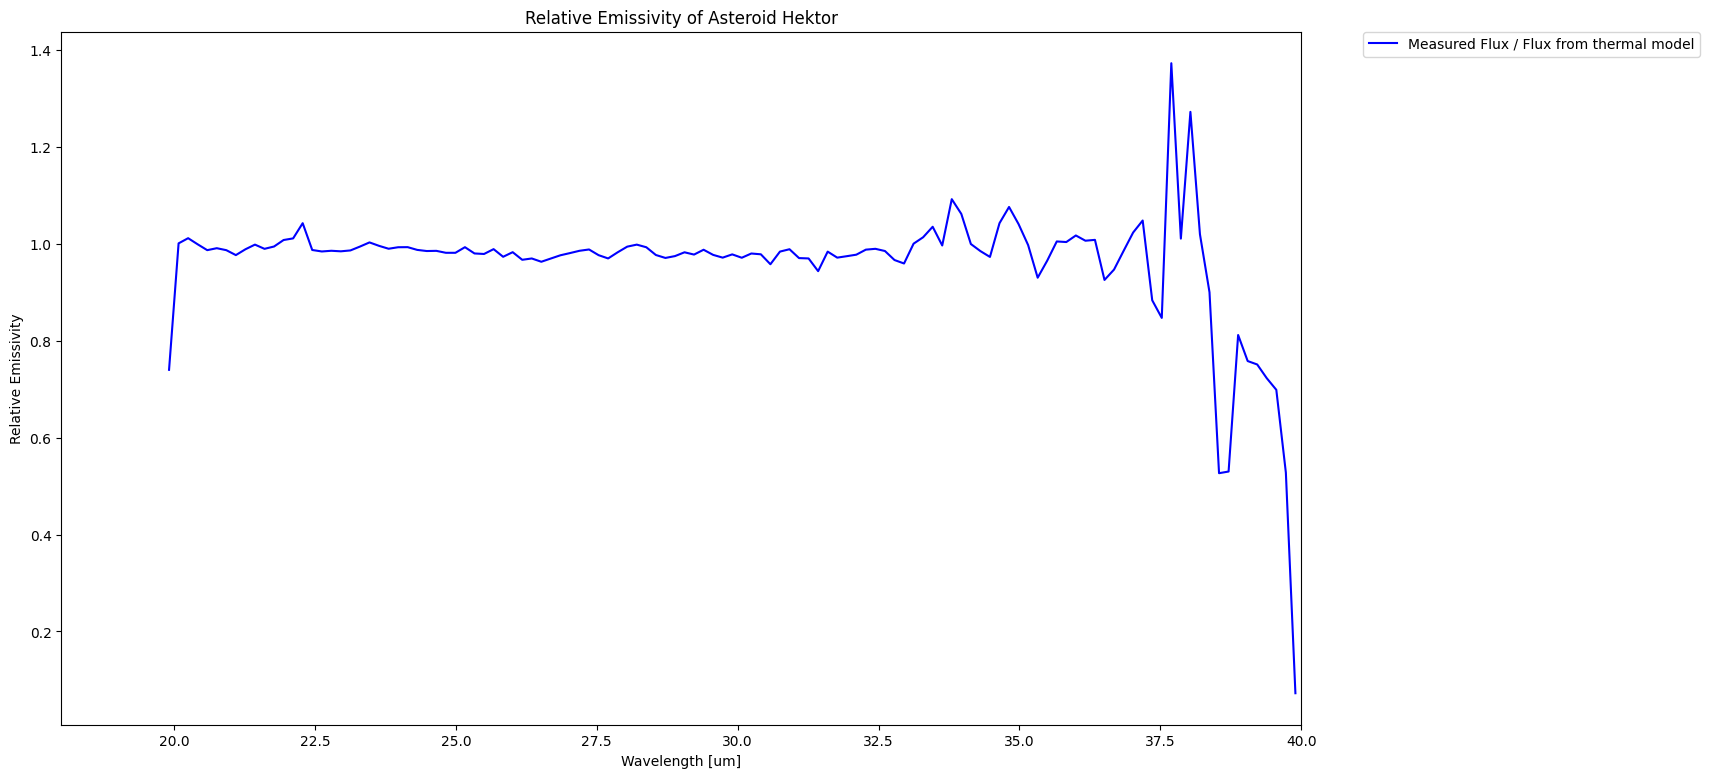

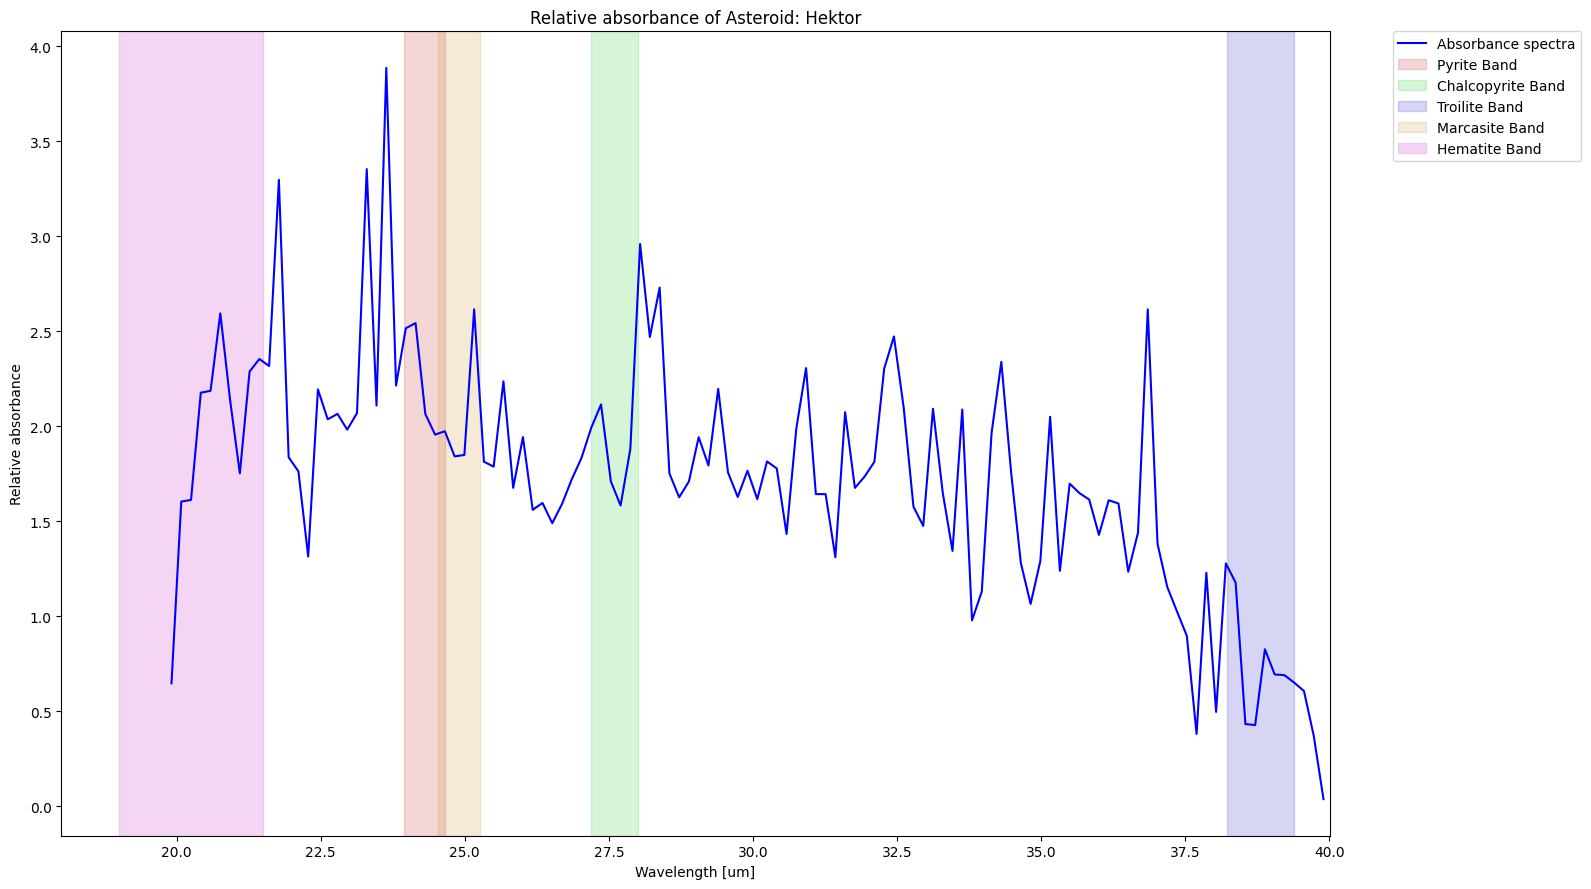

In [ ]:
# Example usage: https://doi.org/10.1016/j.icarus.2006.01.011 - ASTEROID HEKTOR
h = 7.49
g = 0.15
alpha = 10.96 * u.degree
r = 5.19266 * u.AU
delta = 5.2349 * u.AU
#wavelengths = 7.57612 * u.micron
eta = 0.95
pv = 0.038
mJy = True
xrange = (18, 40)
asteroid_name = 'Hektor'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#cc3333'),       # Dark Red
    (27.19, 28.01, 'Chalcopyrite', '#33cc33'), # Dark Green
    (38.22, 39.38, 'Troilite', '#3333cc'),     # Dark Blue
    (24.53, 25.27, 'Marcasite', '#cc9933'),    # Dark Yellow
    (19, 21.5, 'Hematite', '#cc33cc')          # Dark Magenta
]

file_path = '/content/Hektor_flux_density.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength'] * u.micron
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)

# Agamemnon

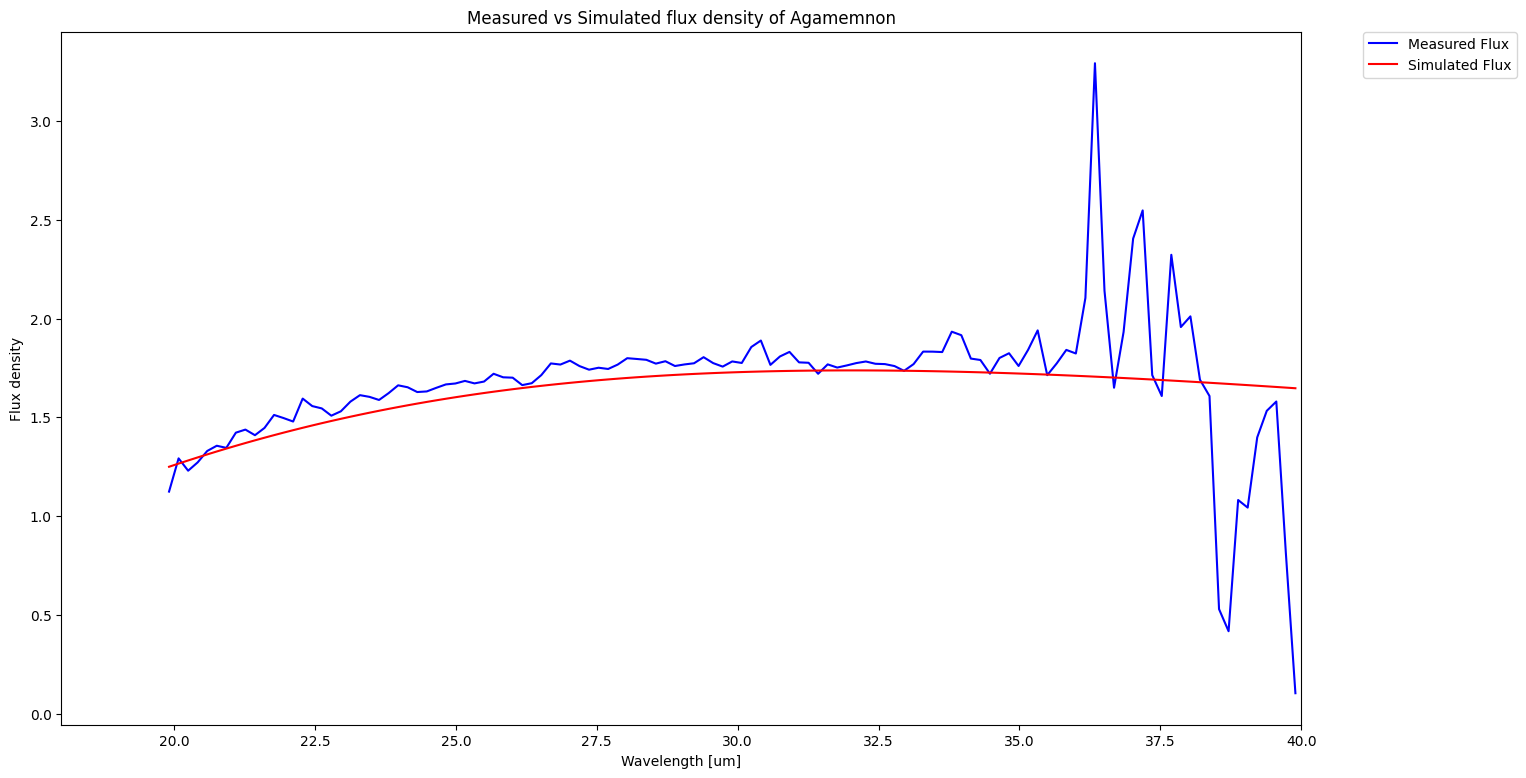

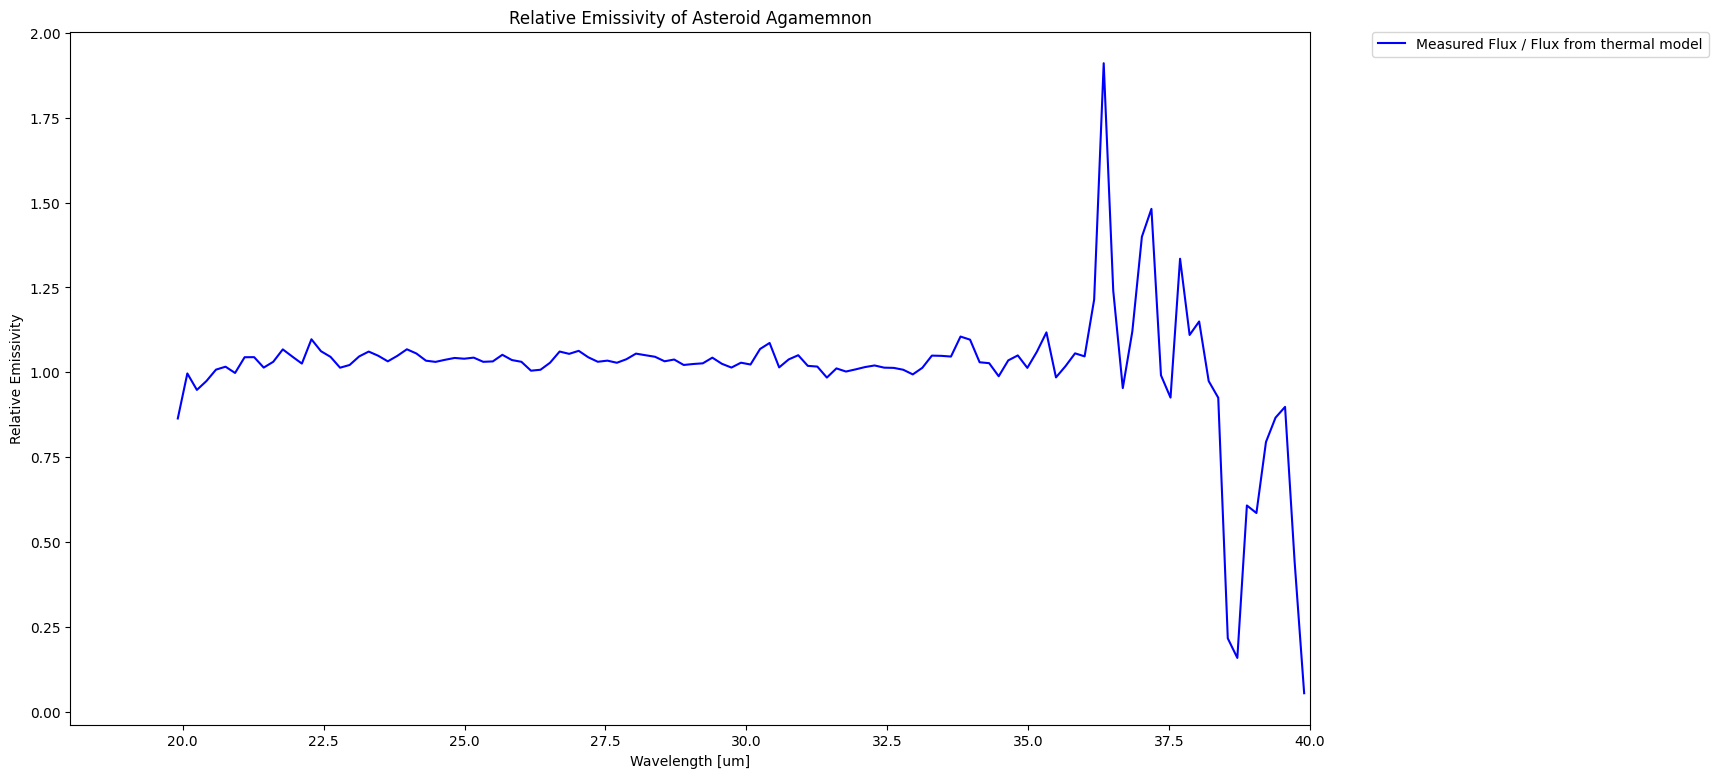

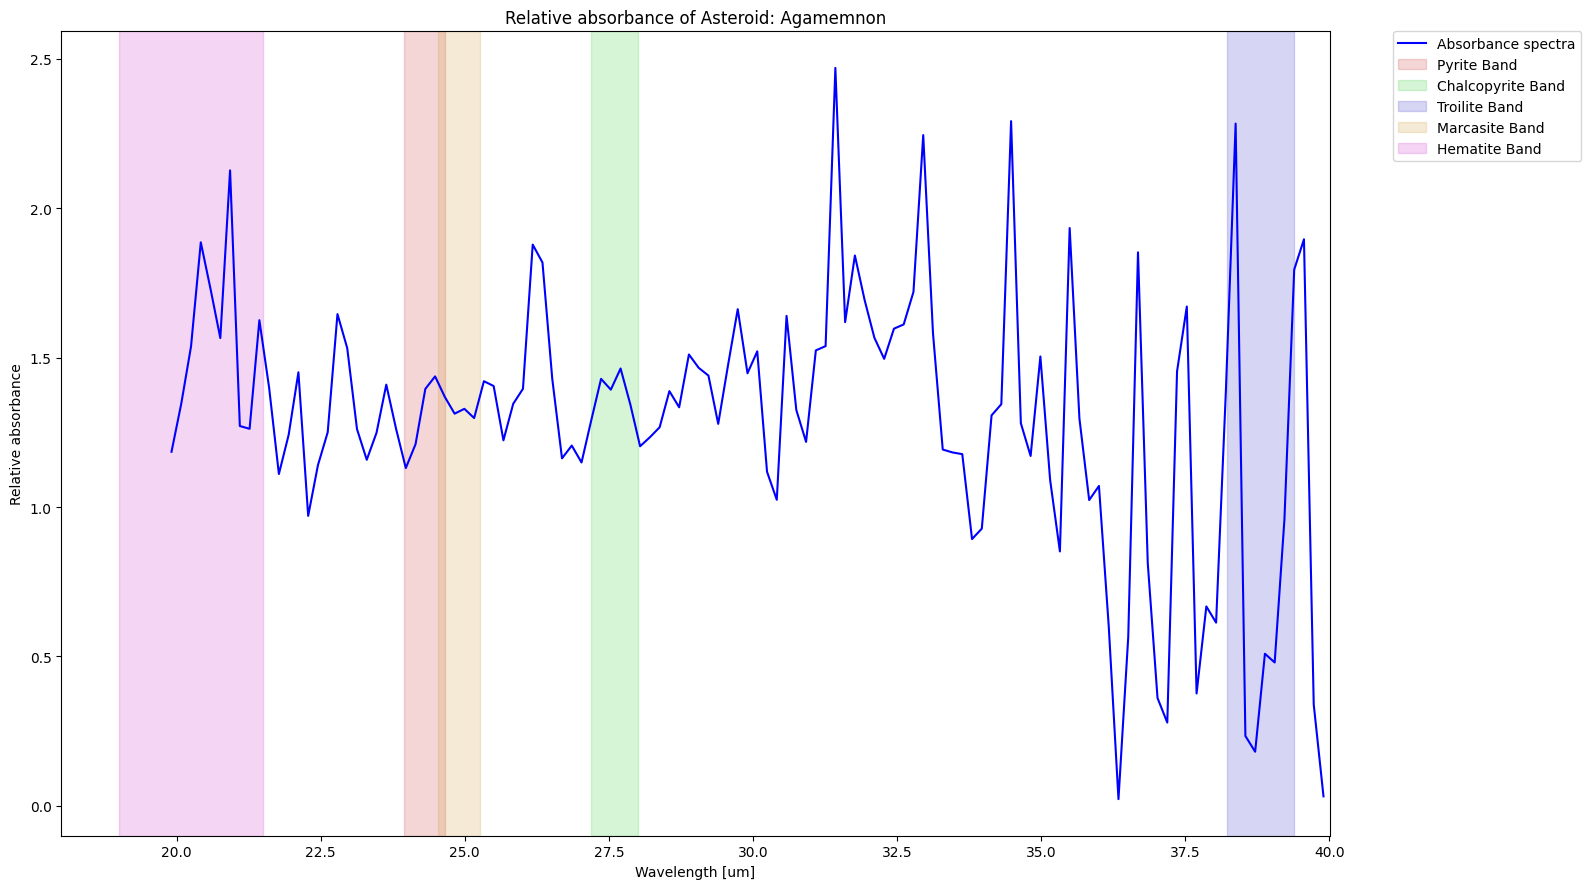

In [ ]:
# Example usage: https://doi.org/10.1016/j.icarus.2006.01.011 - ASTEROID Agamemnon
h = 7.89
g = 0.15
alpha = 10.26 * u.degree
r = 5.59296 * u.AU
delta = 5.2798 * u.AU
#wavelengths = 7.57612 * u.micron
eta = 0.89
pv = 0.058
mJy = True
xrange = (18, 40)
asteroid_name = 'Agamemnon'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#cc3333'),       # Dark Red
    (27.19, 28.01, 'Chalcopyrite', '#33cc33'), # Dark Green
    (38.22, 39.38, 'Troilite', '#3333cc'),     # Dark Blue
    (24.53, 25.27, 'Marcasite', '#cc9933'),    # Dark Yellow
    (19, 21.5, 'Hematite', '#cc33cc')          # Dark Magenta
]


file_path = '/content/Agamemnon.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength'] * u.micron
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)

# Aneas

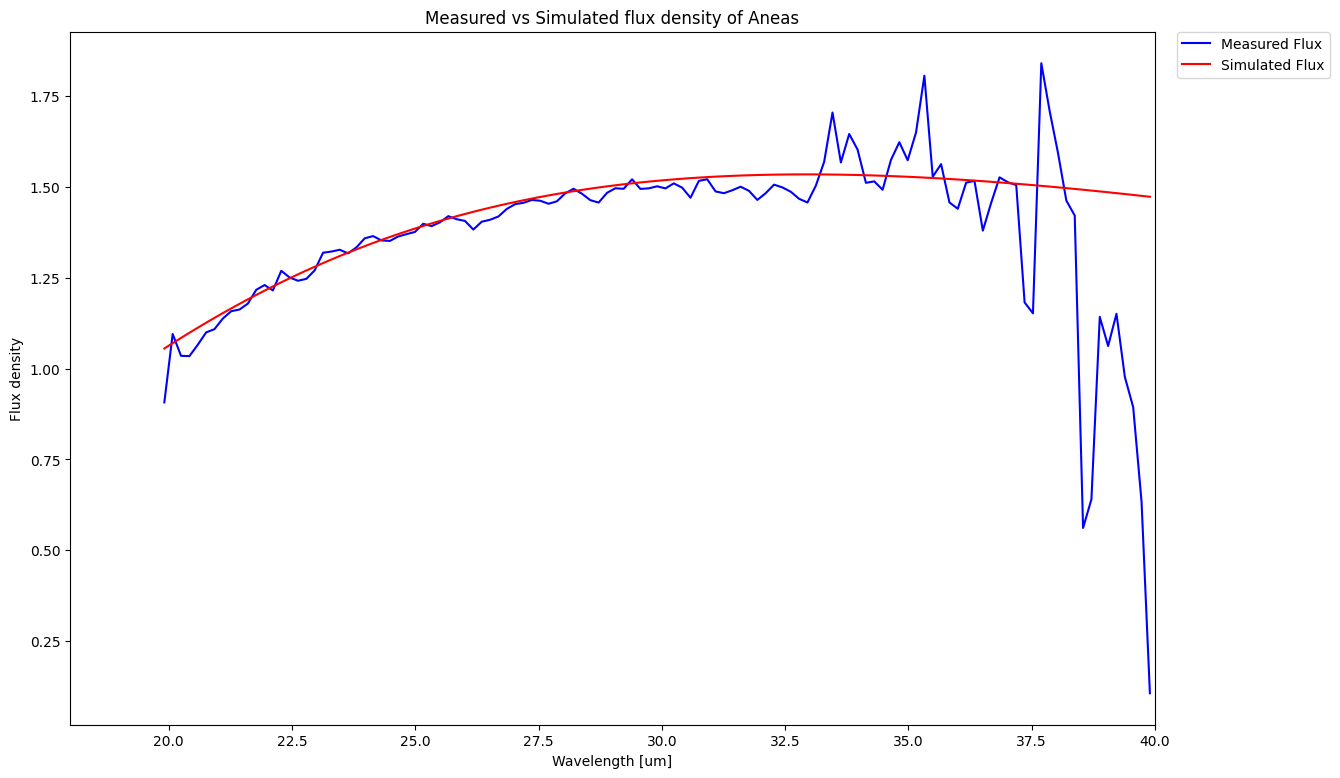

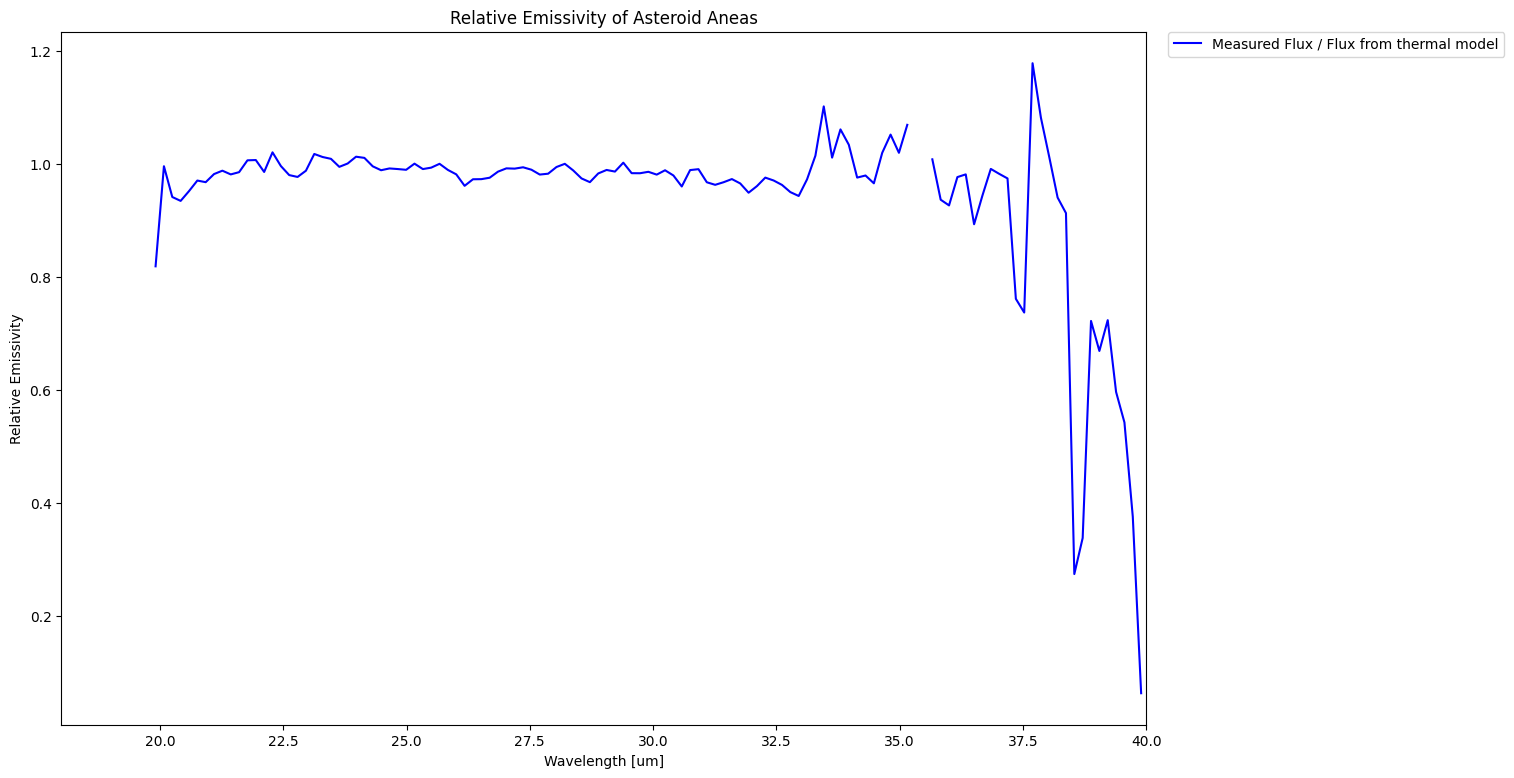

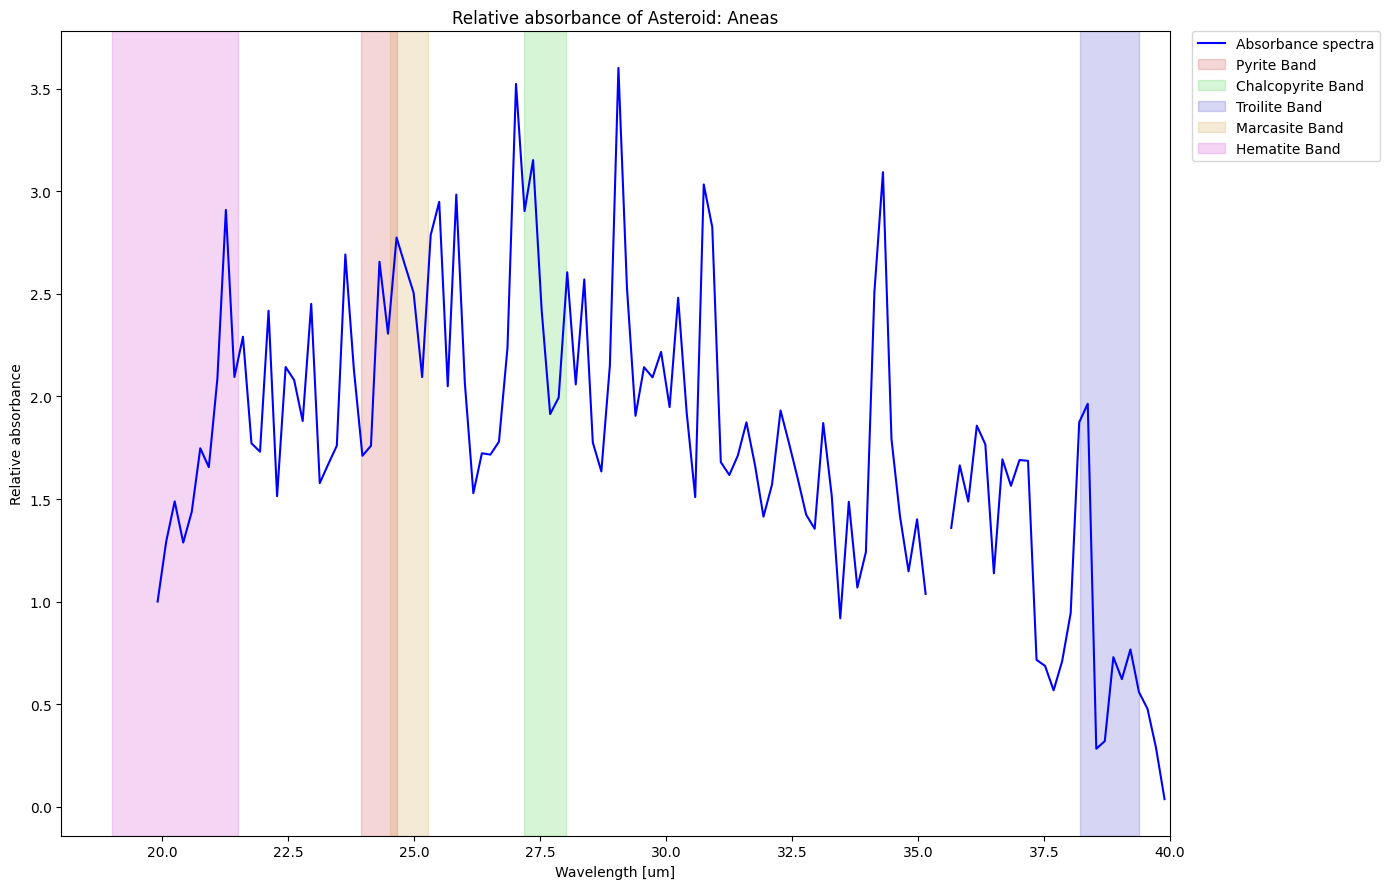

In [ ]:
# Example usage: https://doi.org/10.1016/j.icarus.2006.01.011 - ASTEROID Aneas
h = 8.33
g = 0.15
alpha = 9.83 * u.degree
r = 5.72208 * u.AU
delta = 5.4361 * u.AU
#wavelengths = 7.57612 * u.micron
eta = 0.96
pv = 0.038
mJy = True
xrange = (18, 40)
asteroid_name = 'Aneas'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#cc3333'),       # Dark Red
    (27.19, 28.01, 'Chalcopyrite', '#33cc33'), # Dark Green
    (38.22, 39.38, 'Troilite', '#3333cc'),     # Dark Blue
    (24.53, 25.27, 'Marcasite', '#cc9933'),    # Dark Yellow
    (19, 21.5, 'Hematite', '#cc33cc')          # Dark Magenta
]

file_path = '/content/Aneas.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength'] * u.micron
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)

# Elisa

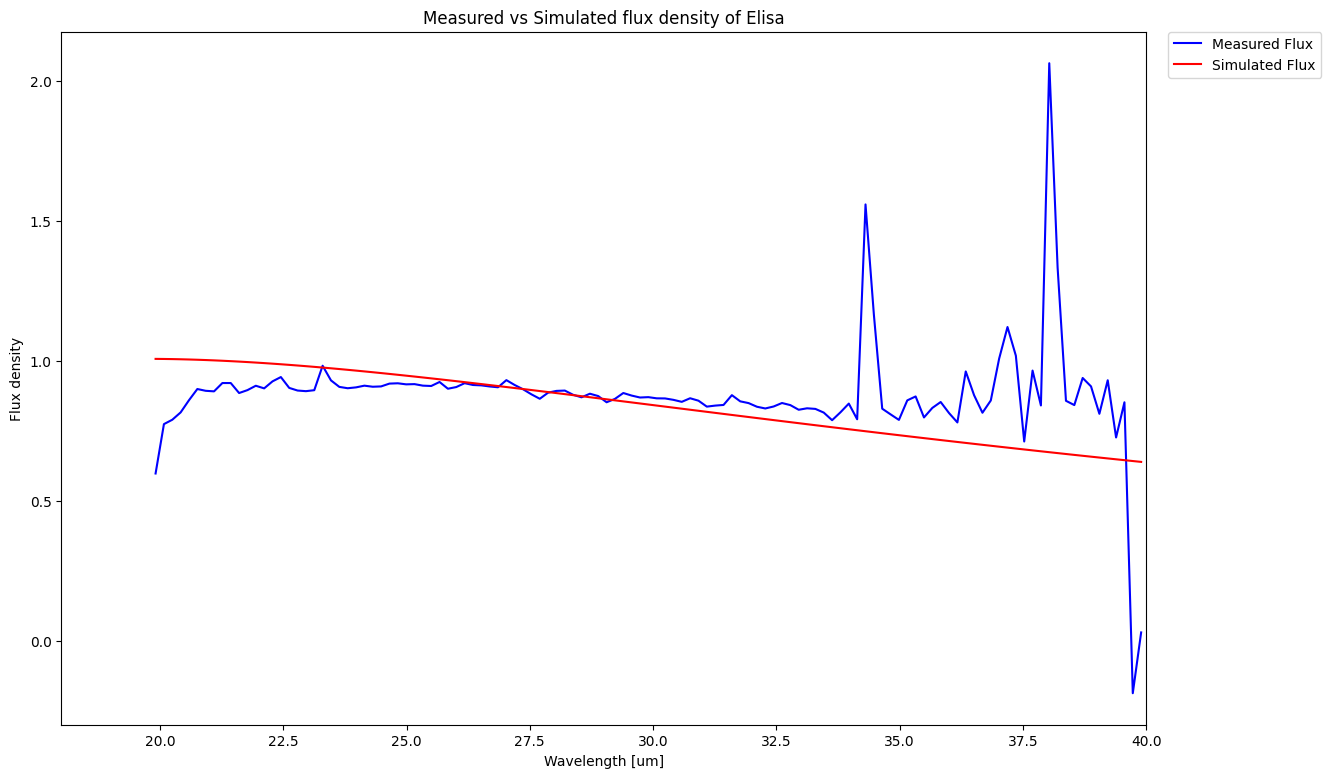

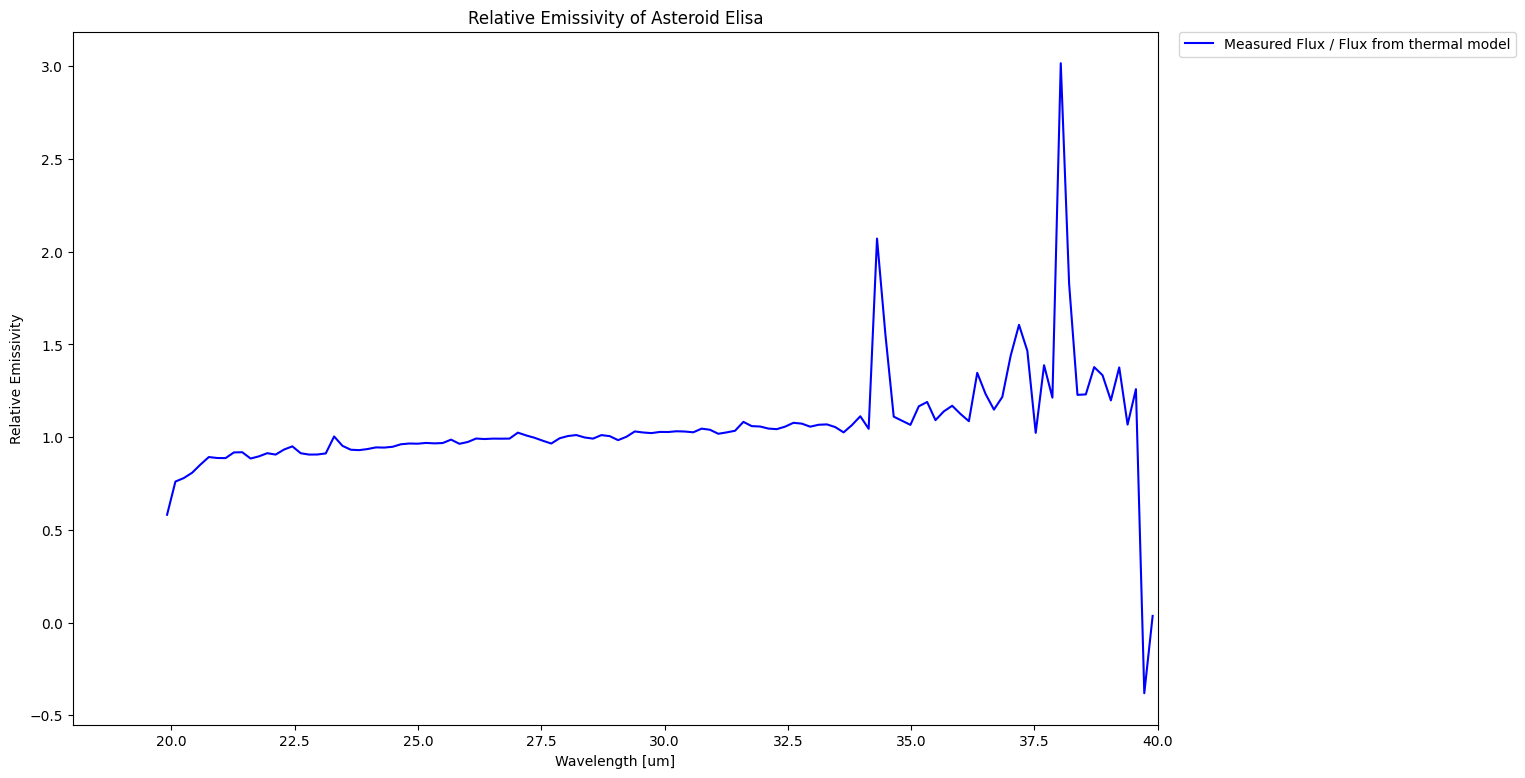

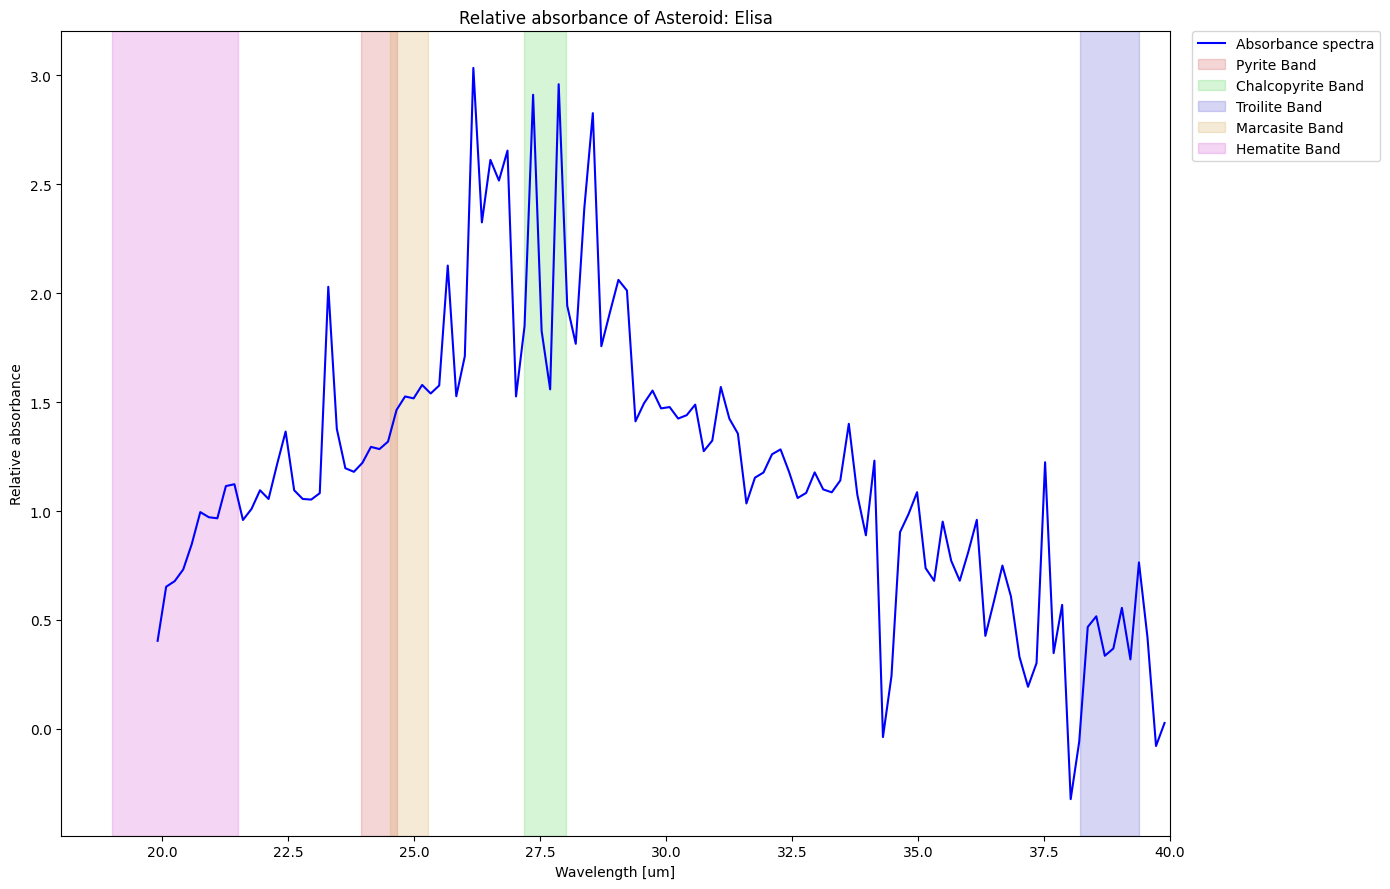

In [ ]:
# Example usage: https://doi.org/10.1016/j.icarus.2010.12.006 - ASTEROID 956 Elisa
h = 12.57
g = 0.24
alpha = 29.32 * u.degree
r = 1.832 * u.AU
delta = 1.110 * u.AU
#wavelengths = 7.57612 * u.micron
eta = 1.12
pv = 0.12
mJy = True
xrange = (18, 40)
asteroid_name = 'Elisa'

bands_to_highlight = [
    (23.94, 24.66, 'Pyrite', '#cc3333'),       # Dark Red
    (27.19, 28.01, 'Chalcopyrite', '#33cc33'), # Dark Green
    (38.22, 39.38, 'Troilite', '#3333cc'),     # Dark Blue
    (24.53, 25.27, 'Marcasite', '#cc9933'),    # Dark Yellow
    (19, 21.5, 'Hematite', '#cc33cc')          # Dark Magenta
]


file_path = '/content/Elisa.csv'
tel_data = telescope_data(file_path)
wavelengths = tel_data.data_df['wavelength'] * u.micron
tel_data.calculate_thermal_flux(h, g, alpha, r, delta, wavelengths, eta, pv, mJy)
tel_data.calculate_flux_ratio()
tel_data.plot_flux_comparison(asteroid_name, xrange)
tel_data.plot_spectra(xrange, asteroid_name)
tel_data.plot_absorption_spectra(xrange, asteroid_name, bands_to_highlight)